<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>02 → K-Nearest Neighbors (KNN) on Iris Dataset</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">(Multiclass Classification, Distance Metrics, Optimal k Tuning, Decision Boundaries & Model Evaluation)</span>
</div>


---

# Table of Contents 

1. [Task 1: Mathematical Foundations & Working Principle of KNN](#1-mathematical-foundations)
2. [Task 2: Import Libraries & Load the Iris Dataset](#2-import-libraries-data)
3. [Task 3: Exploratory Data Analysis (EDA) & Feature Distributions](#3-eda-distributions)
4. [Task 4: Feature Correlation & Morphological Pairwise Analysis](#4-correlation-pairplot)
5. [Task 5: Data Preprocessing & The Critical Role of Feature Scaling](#5-preprocessing-scaling)
6. [Task 6: Train-Test Split with Class Stratification](#6-train-test-split)
7. [Task 7: Baseline KNN Classifier & Initial Performance Benchmark](#7-baseline-knn)
8. [Task 8: Hyperparameter Optimization — Selecting the Optimal k](#8-optimal-k)
9. [Task 9: Distance Metric & Weighting Scheme Grid Search](#9-distance-weights-gridsearch)
10. [Task 10: 2D Decision Boundary Landscapes (Overfitting vs Optimal vs Underfitting)](#10-decision-boundaries)
11. [Task 11: Global Decision Surface Mapping via PCA Projection](#11-pca-decision-surface)
12. [Task 12: Comprehensive Final Model Evaluation (Confusion Matrix & Multiclass ROC-AUC)](#12-model-evaluation)
13. [Task 13: Computational Complexity Analysis & Production Takeaways](#13-summary-takeaways)

---


<a id="1-mathematical-foundations"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">1. Task 1: Mathematical Foundations & Working Principle of KNN</span>


**K-Nearest Neighbors (KNN)** is a non-parametric, instance-based (lazy learning) supervised algorithm. Unlike parametric models that optimize global weights during training, KNN stores the entire training dataset $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^N$ and defers computation until inference time.

### 1. Distance Metrics in Feature Space $\mathbb{R}^d$
Given a query point $\mathbf{x} \in \mathbb{R}^d$ and a training instance $\mathbf{x}_i \in \mathbb{R}^d$:

**1. Euclidean Distance ($L_2$ norm):**

$$
d_2(\mathbf{x}, \mathbf{x}_i) = \|\mathbf{x} - \mathbf{x}_i\|_2 = \sqrt{\sum_{j=1}^d (x_j - x_{i,j})^2}
$$

**2. Manhattan Distance ($L_1$ norm / Taxicab):**

$$
d_1(\mathbf{x}, \mathbf{x}_i) = \|\mathbf{x} - \mathbf{x}_i\|_1 = \sum_{j=1}^d |x_j - x_{i,j}|
$$

**3. Minkowski Distance ($L_p$ generalized norm):**

$$
d_p(\mathbf{x}, \mathbf{x}_i) = \left( \sum_{j=1}^d |x_j - x_{i,j}|^p \right)^{1/p}
$$

### 2. Decision Rules & Voting Strategies

**Uniform Majority Voting:**

$$
\hat{y} = \operatorname{argmax}_{c \in \mathcal{C}} \sum_{i \in \mathcal{N}_k(\mathbf{x})} \mathbf{1}(y_i = c)
$$

**Distance-Weighted Voting:**

$$
w_i = \frac{1}{d(\mathbf{x}, \mathbf{x}_i) + \epsilon} \implies \hat{y} = \operatorname{argmax}_{c \in \mathcal{C}} \sum_{i \in \mathcal{N}_k(\mathbf{x})} w_i \cdot \mathbf{1}(y_i = c)
$$

### 3. The Bias-Variance Tradeoff in KNN
- **Small $k$ (e.g., $k=1$):** Low bias, high variance. The decision boundary is jagged and overly sensitive to noise/outliers (overfitting).
- **Large $k$ (e.g., $k=N$):** High bias, low variance. Every query receives the majority class of the entire dataset (underfitting).


<a id="2-import-libraries-data"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">2. Task 2: Import Libraries & Load the Iris Dataset</span>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    roc_curve, 
    auc, 
    roc_auc_score
)
from sklearn.decomposition import PCA

# Configure plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load Fisher's 1936 Iris Dataset
raw_iris = load_iris()

df = pd.DataFrame(data=raw_iris.data, columns=[
    'sepal_length', 'sepal_width', 'petal_length', 'petal_width'
])
df['species'] = pd.Categorical.from_codes(raw_iris.target, raw_iris.target_names)
df['target'] = raw_iris.target

print(f"Dataset Shape: {df.shape} (150 samples, 4 morphological features, 3 species)")
display(df.head())

Dataset Shape: (150, 6) (150 samples, 4 morphological features, 3 species)


,sepal_length,sepal_width,petal_length,petal_width,species,target
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0


<a id="3-eda-distributions"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">3. Task 3: Exploratory Data Analysis (EDA) & Feature Distributions</span>


In [3]:
# Check summary statistics and missing values
print("--- Missing Values Check ---")
print(df.isnull().sum())
print("\n--- Class Balance ---")
print(df['species'].value_counts())
print("\n--- Statistical Summary ---")
display(df.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']])

--- Missing Values Check ---
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
target          0
dtype: int64

--- Class Balance ---
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

--- Statistical Summary ---


,mean,std,min,25%,50%,75%,max
sepal_length,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal_length,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal_width,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
target,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


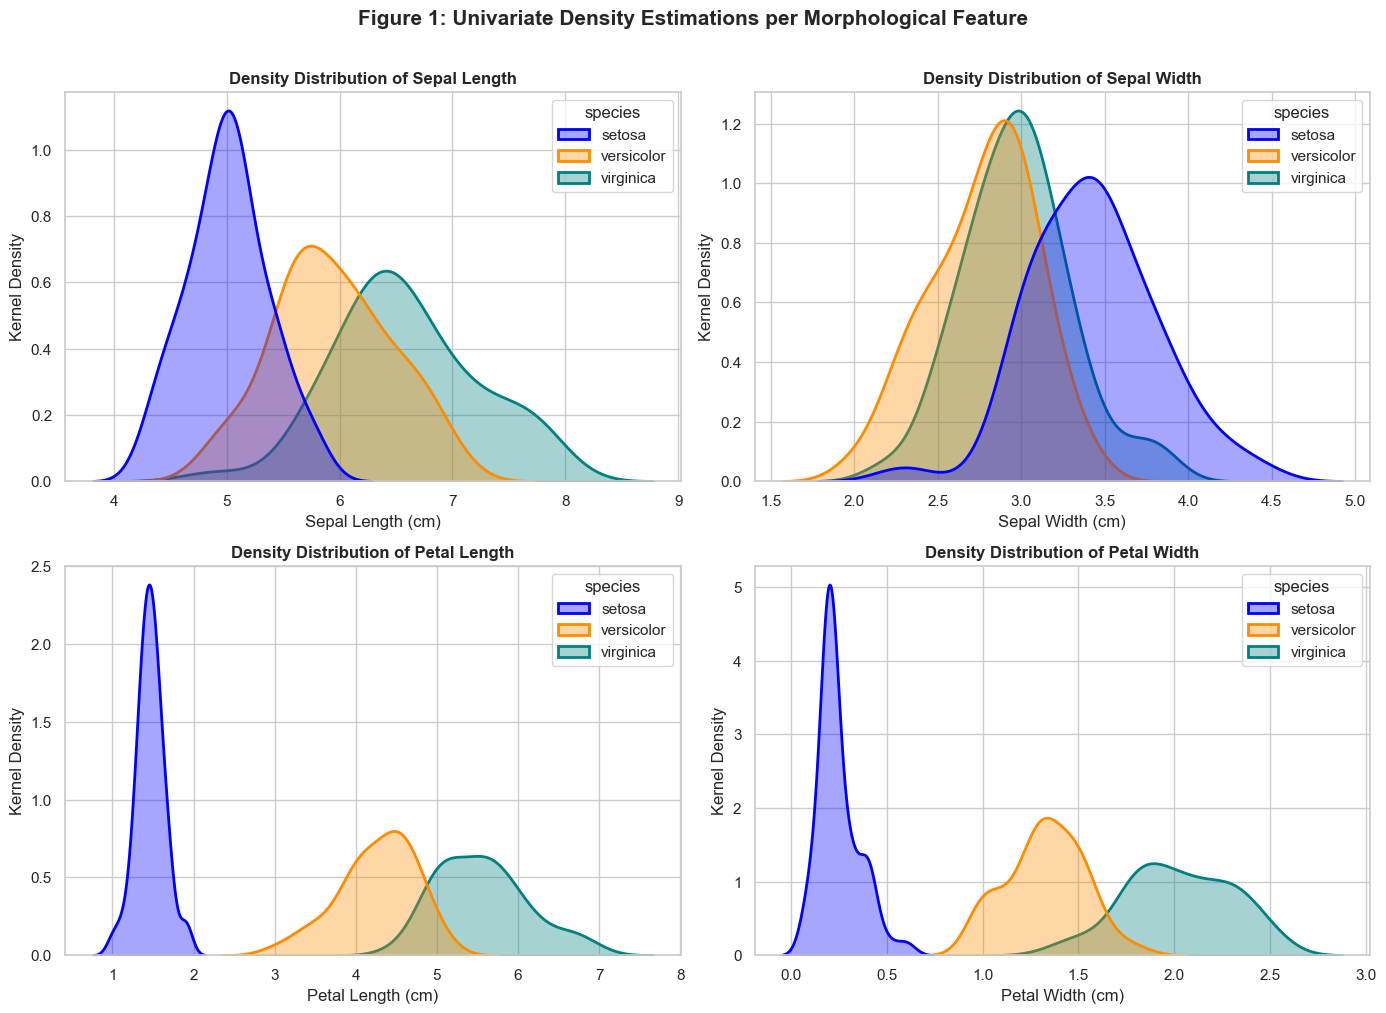

In [4]:
# PLOT 1: Morphological Feature Distributions Across Species
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

palette = {'setosa': 'blue', 'versicolor': 'darkorange', 'virginica': 'teal'}

for idx, feature in enumerate(features):
    sns.kdeplot(
        data=df, x=feature, hue='species', fill=True, common_norm=False, 
        palette=palette, alpha=0.35, linewidth=2, ax=axes[idx]
    )
    axes[idx].set_title(f"Density Distribution of {feature.replace('_', ' ').title()}", fontweight='bold')
    axes[idx].set_xlabel(f"{feature.replace('_', ' ').title()} (cm)")
    axes[idx].set_ylabel("Kernel Density")

plt.suptitle("Figure 1: Univariate Density Estimations per Morphological Feature", y=1.01, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\mohdf\AppData\Local\Temp\ipykernel_4384\3068656725.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=df, palette=palette, ax=axes[idx], width=0.5, boxprops=dict(alpha=0.7))
C:\Users\mohdf\AppData\Local\Temp\ipykernel_4384\3068656725.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=df, palette=palette, ax=axes[idx], width=0.5, boxprops=dict(alpha=0.7))
C:\Users\mohdf\AppData\Local\Temp\ipykernel_4384\3068656725.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='specie

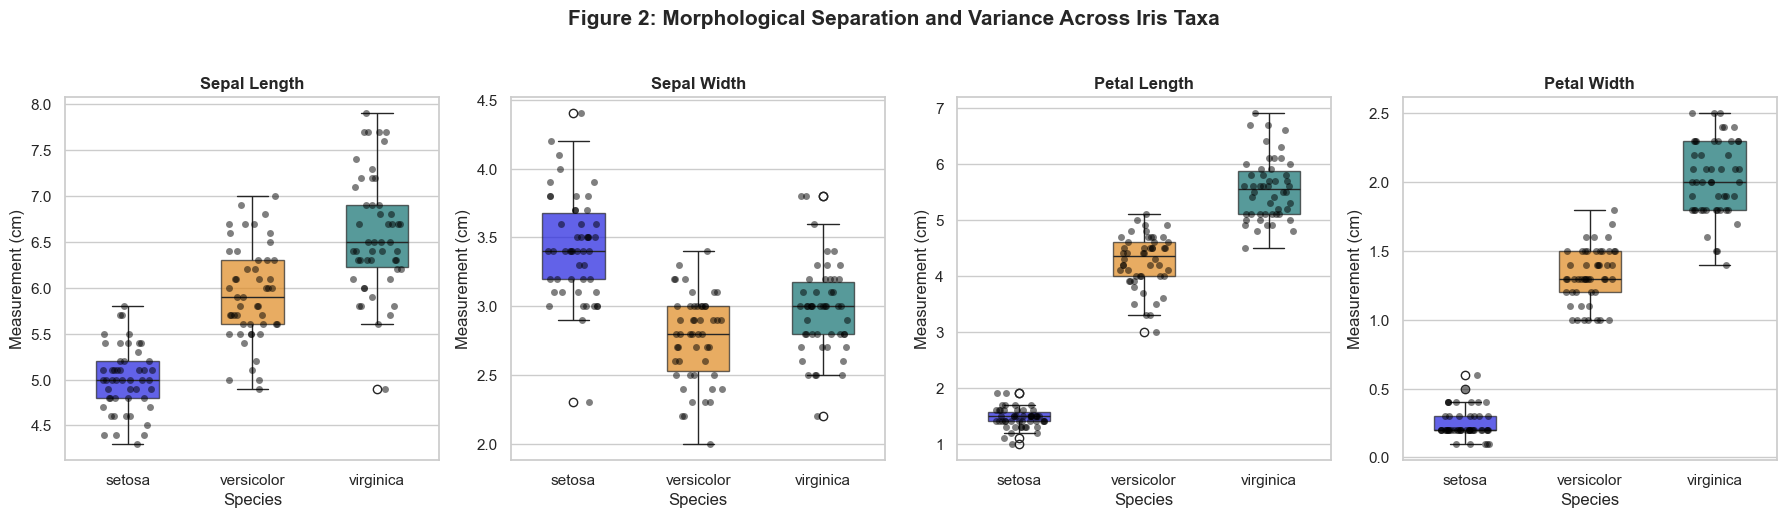

In [5]:
# PLOT 2: Morphological Box & Strip Plots for Separation Analysis
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for idx, feature in enumerate(features):
    sns.boxplot(x='species', y=feature, data=df, palette=palette, ax=axes[idx], width=0.5, boxprops=dict(alpha=0.7))
    sns.stripplot(x='species', y=feature, data=df, color='black', alpha=0.5, jitter=0.2, size=5, ax=axes[idx])
    axes[idx].set_title(f"{feature.replace('_', ' ').title()}", fontweight='bold')
    axes[idx].set_xlabel("Species")
    axes[idx].set_ylabel("Measurement (cm)")

plt.suptitle("Figure 2: Morphological Separation and Variance Across Iris Taxa", y=1.03, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

<a id="4-correlation-pairplot"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">4. Task 4: Feature Correlation & Morphological Pairwise Analysis</span>


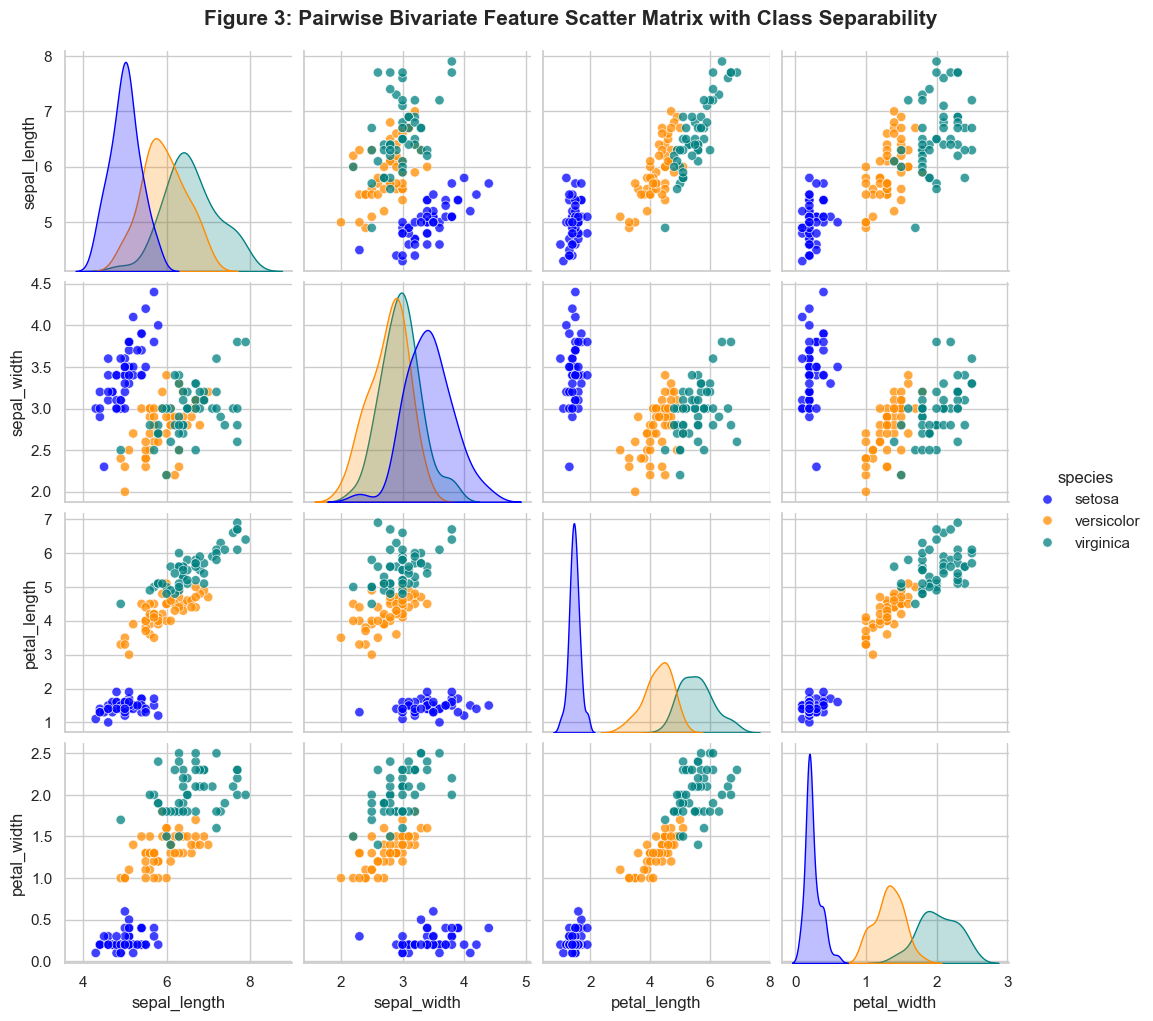

In [6]:
# PLOT 3: Pairwise Bivariate Relationships (Pairplot)
pair_fig = sns.pairplot(
    df, vars=features, hue='species', palette=palette, 
    diag_kind='kde', plot_kws={'alpha': 0.75, 's': 45}, height=2.6
)
pair_fig.fig.subplots_adjust(top=0.94)
pair_fig.fig.suptitle("Figure 3: Pairwise Bivariate Feature Scatter Matrix with Class Separability", fontsize=15, fontweight='bold')
plt.show()

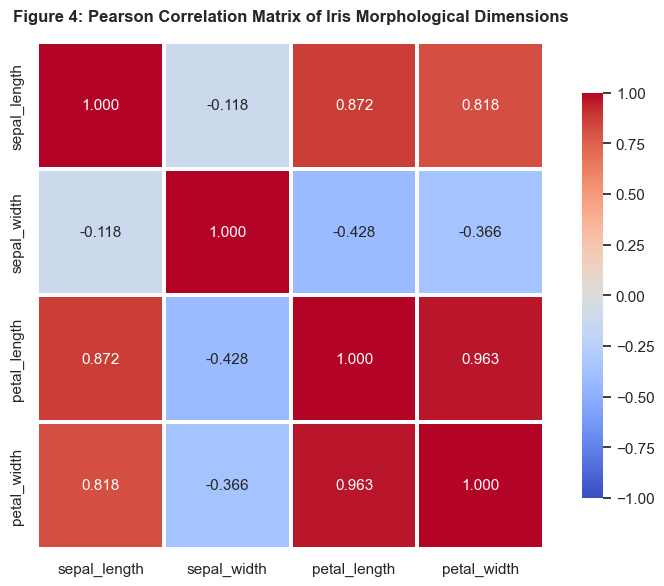

In [7]:
# PLOT 4: Correlation Matrix Heatmap
plt.figure(figsize=(8, 6))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr, annot=True, fmt=".3f", cmap='coolwarm', vmin=-1, vmax=1, 
    square=True, linewidths=1.5, cbar_kws={"shrink": 0.8}
)
plt.title("Figure 4: Pearson Correlation Matrix of Iris Morphological Dimensions", pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

<a id="5-preprocessing-scaling"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">5. Task 5: Data Preprocessing & The Critical Role of Feature Scaling</span>


**Beginner Note - The Importance of Feature Scaling for Distance Models:**
- KNN determines neighbors strictly using metric distance: $d = \sqrt{\sum_j (x_j - x_{i,j})^2}$.
- If one feature has values from $0.1$ to $2.5$ (e.g. Petal Width) while another has values from $50$ to $2500$ (e.g. Salary in other datasets), the larger feature will completely dominate Euclidean distance calculations!
- `StandardScaler` transforms every feature to have $\mu = 0$ and $\sigma = 1$:
  $$z = \frac{x - \mu}{\sigma}$$


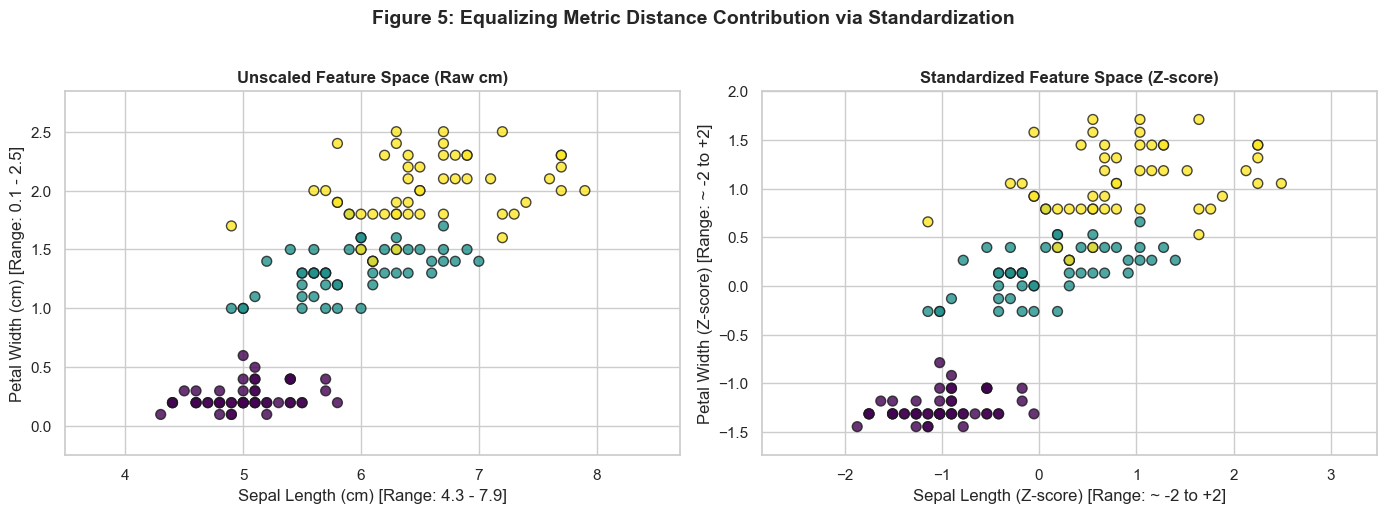

In [8]:
# PLOT 5: Visualizing Feature Distortion Before and After StandardScaler
X_raw = df[features].values
y_all = df['target'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Unscaled space: Sepal Length vs Petal Width
ax1.scatter(X_raw[:, 0], X_raw[:, 3], c=y_all, cmap='viridis', edgecolors='k', s=50, alpha=0.8)
ax1.set_title("Unscaled Feature Space (Raw cm)", fontweight='bold')
ax1.set_xlabel("Sepal Length (cm) [Range: 4.3 - 7.9]")
ax1.set_ylabel("Petal Width (cm) [Range: 0.1 - 2.5]")
ax1.axis('equal')

# Scaled space: Z-scores
ax2.scatter(X_scaled[:, 0], X_scaled[:, 3], c=y_all, cmap='viridis', edgecolors='k', s=50, alpha=0.8)
ax2.set_title("Standardized Feature Space (Z-score)", fontweight='bold')
ax2.set_xlabel("Sepal Length (Z-score) [Range: ~ -2 to +2]")
ax2.set_ylabel("Petal Width (Z-score) [Range: ~ -2 to +2]")
ax2.axis('equal')

plt.suptitle("Figure 5: Equalizing Metric Distance Contribution via Standardization", y=1.02, fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

<a id="6-train-test-split"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">6. Task 6: Train-Test Split with Class Stratification</span>


In [9]:
# Stratified train-test split (70% train, 30% test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_all, test_size=0.30, random_state=42, stratify=y_all
)

# Fit scaler strictly on training set to prevent data leakage!
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Training set: {X_train.shape[0]} samples (Class counts: {np.bincount(y_train)})")
print(f"Testing set:  {X_test.shape[0]} samples (Class counts: {np.bincount(y_test)})")

Training set: 105 samples (Class counts: [35 35 35])
Testing set:  45 samples (Class counts: [15 15 15])


<a id="7-baseline-knn"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">7. Task 7: Baseline KNN Classifier & Initial Performance Benchmark</span>


In [10]:
# Initialize baseline KNN with arbitrary k=3
knn_baseline = KNeighborsClassifier(n_neighbors=3, weights='uniform', metric='euclidean')
knn_baseline.fit(X_train, y_train)

# Evaluate on test set
y_pred_base = knn_baseline.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)

print(f"Baseline KNN (k=3) Test Accuracy: {acc_base * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_base, target_names=raw_iris.target_names))

Baseline KNN (k=3) Test Accuracy: 91.11%

Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



<a id="8-optimal-k"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">8. Task 8: Hyperparameter Optimization — Selecting the Optimal k</span>


**Beginner Note - Stratified K-Fold Cross-Validation:**
- Evaluating a model on only a single test set can be noisy, especially on small datasets.
- 10-Fold Stratified Cross-Validation splits the training data into 10 balanced folds, training on 9 and validating on the 10th repeatedly.
- We evaluate every $k$ from $1$ to $35$ to find the peak cross-validated performance.


<>:29: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:29: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\mohdf\AppData\Local\Temp\ipykernel_4384\3669480039.py:29: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  ax1.fill_between(k_range, cv_mean_scores - cv_std_scores, cv_mean_scores + cv_std_scores, color='blue', alpha=0.18, label='$\pm 1$ Std Dev')


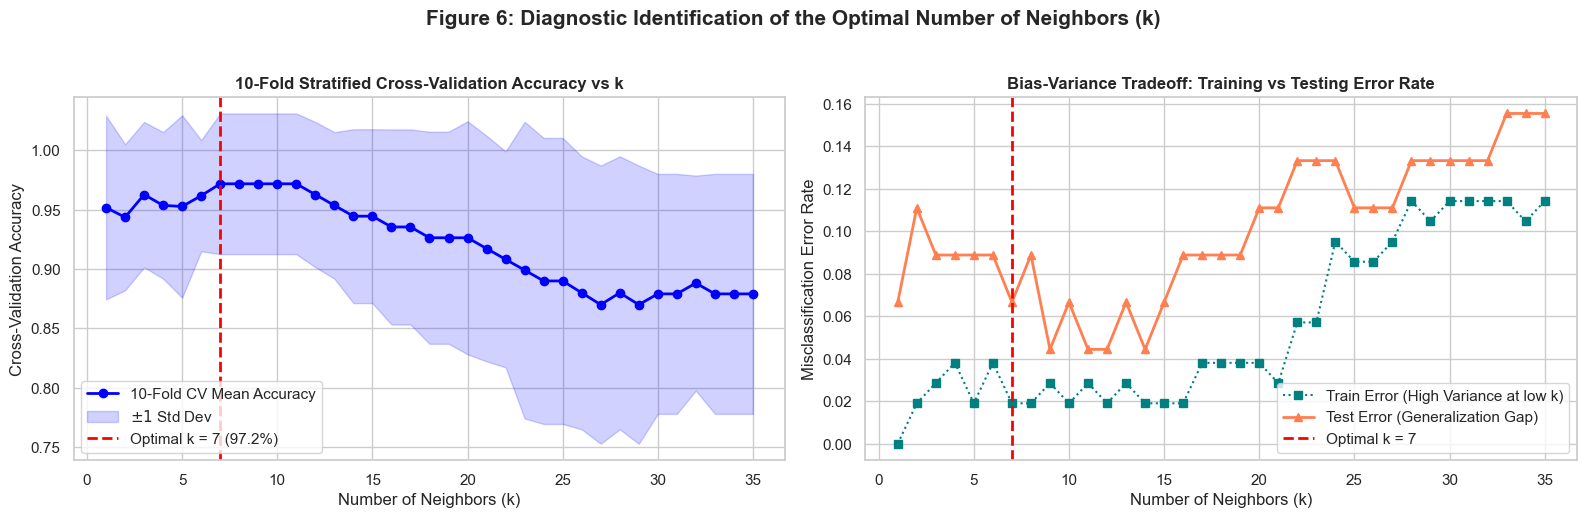

Optimal k determined by Stratified 10-Fold CV: k = 7 with 97.18% accuracy


In [11]:
# PLOT 6: Bias-Variance Curve & Error Rate vs Choice of k
k_range = list(range(1, 36))
cv_mean_scores = []
cv_std_scores = []
train_errors = []
test_errors = []

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    cv_mean_scores.append(scores.mean())
    cv_std_scores.append(scores.std())
    
    # Train vs test error
    model.fit(X_train, y_train)
    train_errors.append(1.0 - accuracy_score(y_train, model.predict(X_train)))
    test_errors.append(1.0 - accuracy_score(y_test, model.predict(X_test)))

cv_mean_scores = np.array(cv_mean_scores)
cv_std_scores = np.array(cv_std_scores)
optimal_k = k_range[np.argmax(cv_mean_scores)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot (a): 10-Fold CV Accuracy with Error Band
ax1.plot(k_range, cv_mean_scores, color='blue', marker='o', linewidth=2, label='10-Fold CV Mean Accuracy')
ax1.fill_between(k_range, cv_mean_scores - cv_std_scores, cv_mean_scores + cv_std_scores, color='blue', alpha=0.18, label='$\pm 1$ Std Dev')
ax1.axvline(optimal_k, color='red', linestyle='--', linewidth=2, label=f'Optimal k = {optimal_k} ({cv_mean_scores[optimal_k-1]*100:.1f}%)')
ax1.set_title("10-Fold Stratified Cross-Validation Accuracy vs k", fontweight='bold')
ax1.set_xlabel("Number of Neighbors (k)")
ax1.set_ylabel("Cross-Validation Accuracy")
ax1.legend(loc='lower left')

# Plot (b): Misclassification Error Rate (Train vs Test)
ax2.plot(k_range, train_errors, color='teal', marker='s', linestyle=':', label='Train Error (High Variance at low k)')
ax2.plot(k_range, test_errors, color='coral', marker='^', linewidth=2, label='Test Error (Generalization Gap)')
ax2.axvline(optimal_k, color='red', linestyle='--', linewidth=2, label=f'Optimal k = {optimal_k}')
ax2.set_title("Bias-Variance Tradeoff: Training vs Testing Error Rate", fontweight='bold')
ax2.set_xlabel("Number of Neighbors (k)")
ax2.set_ylabel("Misclassification Error Rate")
ax2.legend()

plt.suptitle("Figure 6: Diagnostic Identification of the Optimal Number of Neighbors (k)", y=1.03, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

print(f"Optimal k determined by Stratified 10-Fold CV: k = {optimal_k} with {cv_mean_scores[optimal_k-1]*100:.2f}% accuracy")

<a id="9-distance-weights-gridsearch"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">9. Task 9: Distance Metric & Weighting Scheme Grid Search</span>


Best Hyperparameters: {'metric': 'euclidean', 'n_neighbors': 19, 'weights': 'distance'}
Best Cross-Validation Accuracy: 98.09%


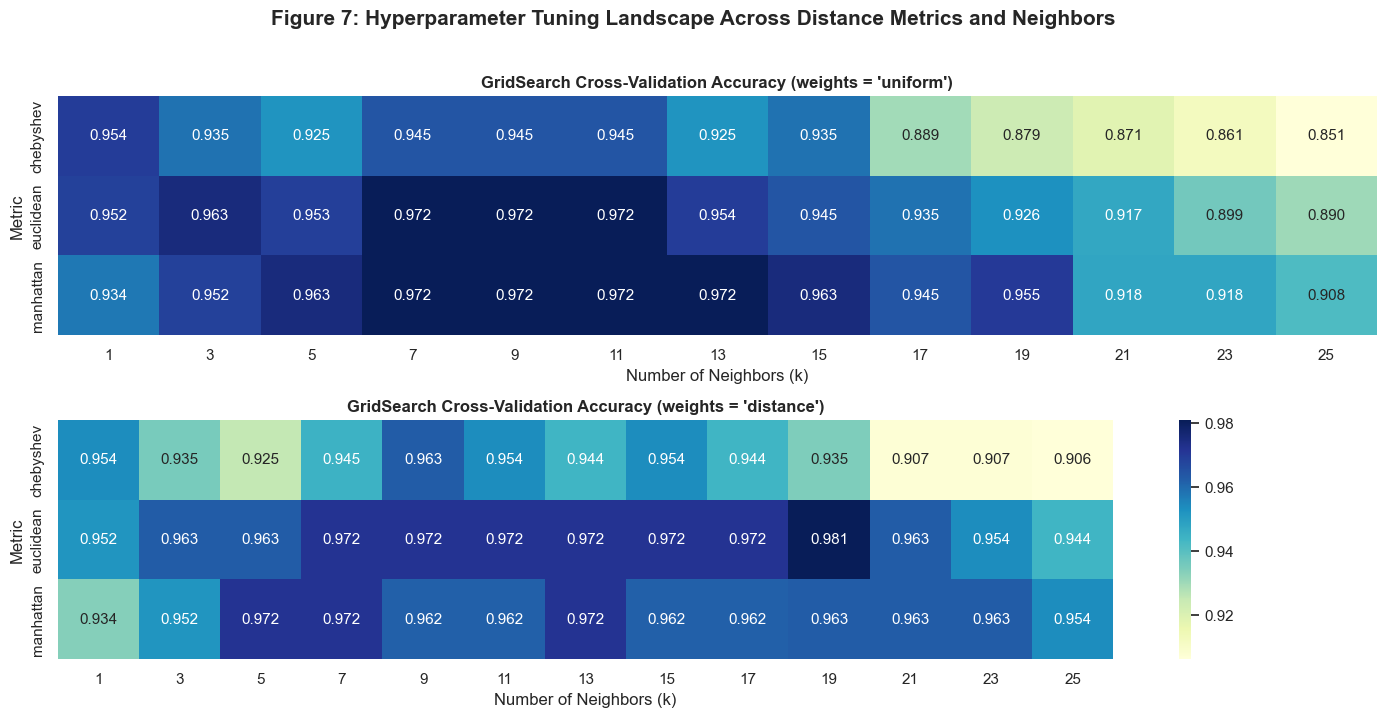

In [12]:
# PLOT 7: Comprehensive GridSearchCV over k, weights, and distance metric
param_grid = {
    'n_neighbors': list(range(1, 26, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'chebyshev']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=1
)
grid_search.fit(X_train, y_train)

best_knn = grid_search.best_estimator_
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%")

# Visualize results as heatmaps
results_df = pd.DataFrame(grid_search.cv_results_)
pivot_uniform = results_df[results_df['param_weights'] == 'uniform'].pivot(
    index='param_metric', columns='param_n_neighbors', values='mean_test_score'
)
pivot_distance = results_df[results_df['param_weights'] == 'distance'].pivot(
    index='param_metric', columns='param_n_neighbors', values='mean_test_score'
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))

sns.heatmap(pivot_uniform, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax1, cbar=False)
ax1.set_title("GridSearch Cross-Validation Accuracy (weights = 'uniform')", fontweight='bold')
ax1.set_xlabel("Number of Neighbors (k)")
ax1.set_ylabel("Metric")

sns.heatmap(pivot_distance, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax2)
ax2.set_title("GridSearch Cross-Validation Accuracy (weights = 'distance')", fontweight='bold')
ax2.set_xlabel("Number of Neighbors (k)")
ax2.set_ylabel("Metric")

plt.suptitle("Figure 7: Hyperparameter Tuning Landscape Across Distance Metrics and Neighbors", y=1.02, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

<a id="10-decision-boundaries"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">10. Task 10: 2D Decision Boundary Landscapes (Overfitting vs Optimal vs Underfitting)</span>


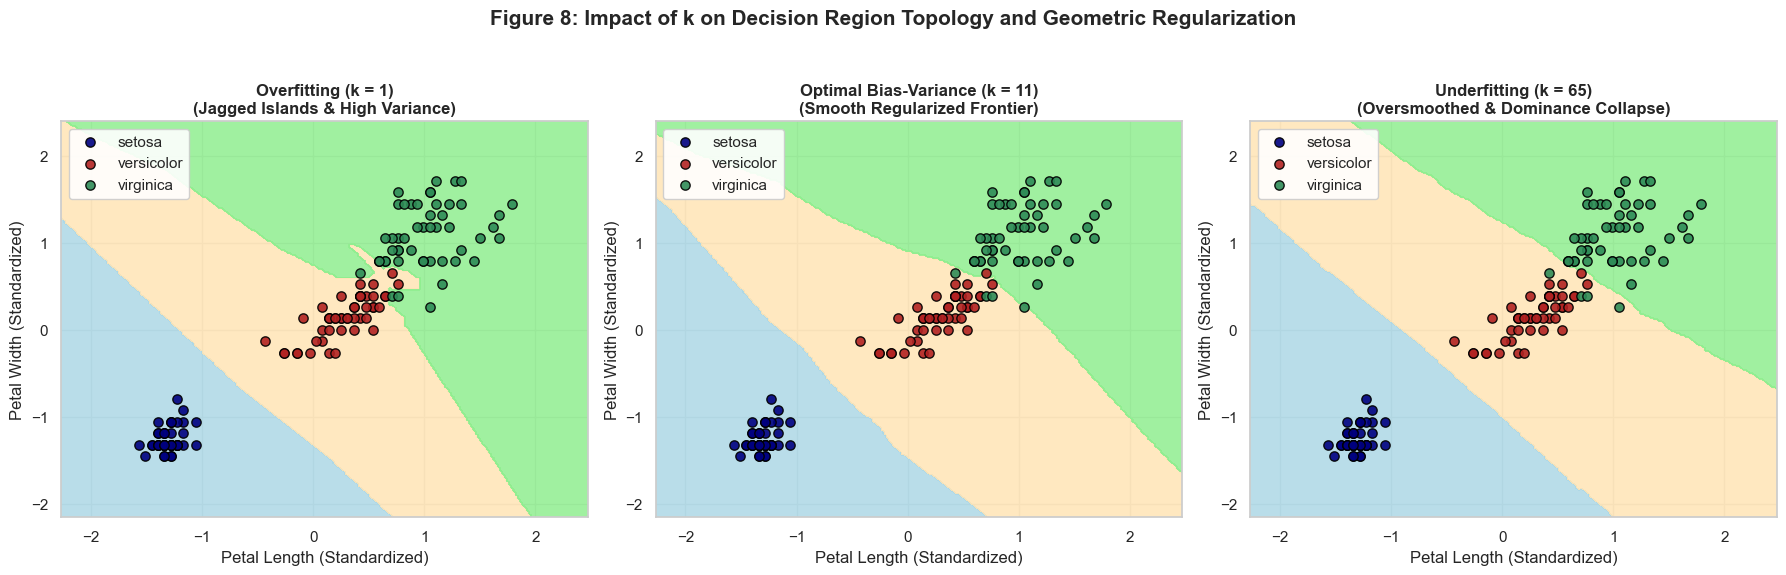

In [13]:
# PLOT 8: High-Resolution 2D Decision Boundaries Across Varying k
# Use Petal Length (idx 2) and Petal Width (idx 3) for clean 2D visualization
X_2d = X_raw[:, [2, 3]]
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

x_min, x_max = X_2d_scaled[:, 0].min() - 0.7, X_2d_scaled[:, 0].max() + 0.7
y_min, y_max = X_2d_scaled[:, 1].min() - 0.7, X_2d_scaled[:, 1].max() + 0.7
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
k_experiments = [(1, "Overfitting (k = 1)", "Jagged Islands & High Variance"),
                 (11, "Optimal Bias-Variance (k = 11)", "Smooth Regularized Frontier"),
                 (65, "Underfitting (k = 65)", "Oversmoothed & Dominance Collapse")]

from matplotlib.colors import ListedColormap
cmap_light = ListedColormap(['lightblue', 'moccasin', 'lightgreen'])
cmap_bold = ['navy', 'firebrick', 'seagreen']

for idx, (k_val, title, subtitle) in enumerate(k_experiments):
    clf = KNeighborsClassifier(n_neighbors=k_val)
    clf.fit(X_2d_scaled, y_all)
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z, cmap=cmap_light, alpha=0.85)
    
    for class_idx, class_name in enumerate(raw_iris.target_names):
        subset = X_2d_scaled[y_all == class_idx]
        axes[idx].scatter(subset[:, 0], subset[:, 1], c=cmap_bold[class_idx],
                          edgecolor='black', s=45, label=class_name, alpha=0.9)
    
    axes[idx].set_title(f"{title}\n({subtitle})", fontweight='bold', fontsize=12)
    axes[idx].set_xlabel("Petal Length (Standardized)")
    axes[idx].set_ylabel("Petal Width (Standardized)")
    axes[idx].legend(loc='upper left', framealpha=0.9)

plt.suptitle("Figure 8: Impact of k on Decision Region Topology and Geometric Regularization", y=1.04, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

<a id="11-pca-decision-surface"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">11. Task 11: Global Decision Surface Mapping via PCA Projection</span>


PC1 explains 72.96% variance | PC2 explains 22.85% variance (Total: 95.81%)


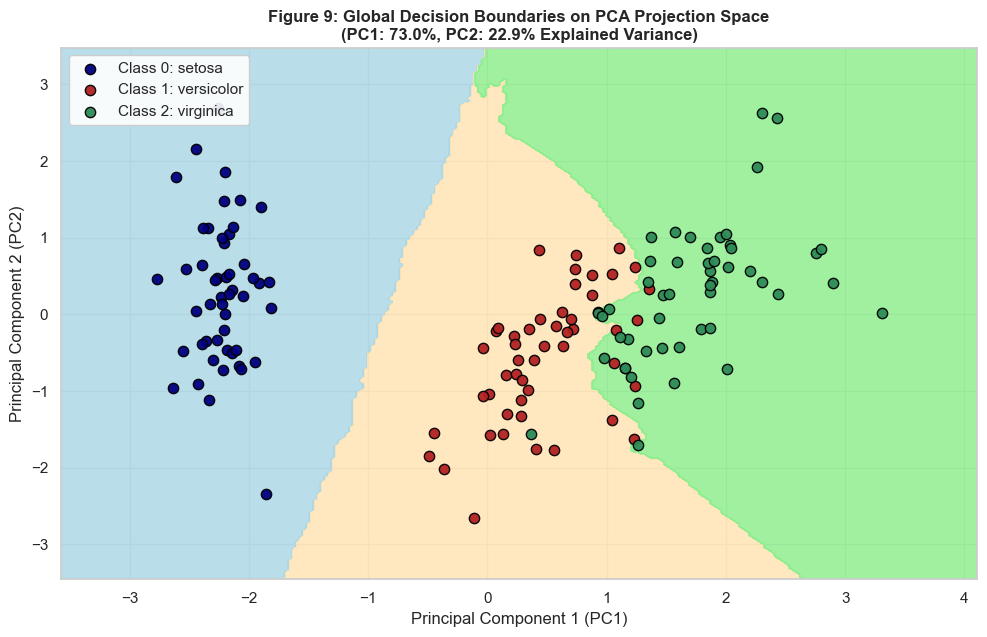

In [14]:
# PLOT 9: Global 4D Feature Projection via PCA with KNN Decision Regions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
print(f"PC1 explains {var_exp[0]*100:.2f}% variance | PC2 explains {var_exp[1]*100:.2f}% variance (Total: {sum(var_exp)*100:.2f}%)")

clf_pca = KNeighborsClassifier(n_neighbors=best_knn.n_neighbors, weights=best_knn.weights, metric=best_knn.metric)
clf_pca.fit(X_pca, y_all)

# Generate meshgrid in PCA coordinate space
x_min, x_max = X_pca[:, 0].min() - 0.8, X_pca[:, 0].max() + 0.8
y_min, y_max = X_pca[:, 1].min() - 0.8, X_pca[:, 1].max() + 0.8
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.03), np.arange(y_min, y_max, 0.03))

Z = clf_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 6.5))
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.85)

for class_idx, class_name in enumerate(raw_iris.target_names):
    subset = X_pca[y_all == class_idx]
    plt.scatter(subset[:, 0], subset[:, 1], c=cmap_bold[class_idx],
                edgecolor='black', s=55, label=f"Class {class_idx}: {class_name}", alpha=0.95)

plt.title(f"Figure 9: Global Decision Boundaries on PCA Projection Space\n(PC1: {var_exp[0]*100:.1f}%, PC2: {var_exp[1]*100:.1f}% Explained Variance)", fontweight='bold')
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(framealpha=0.9, loc='upper left')
plt.tight_layout()
plt.show()

<a id="12-model-evaluation"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">12. Task 12: Comprehensive Final Model Evaluation (Confusion Matrix & Multiclass ROC-AUC)</span>


Final Tuned KNN Classifier Accuracy: 91.11%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



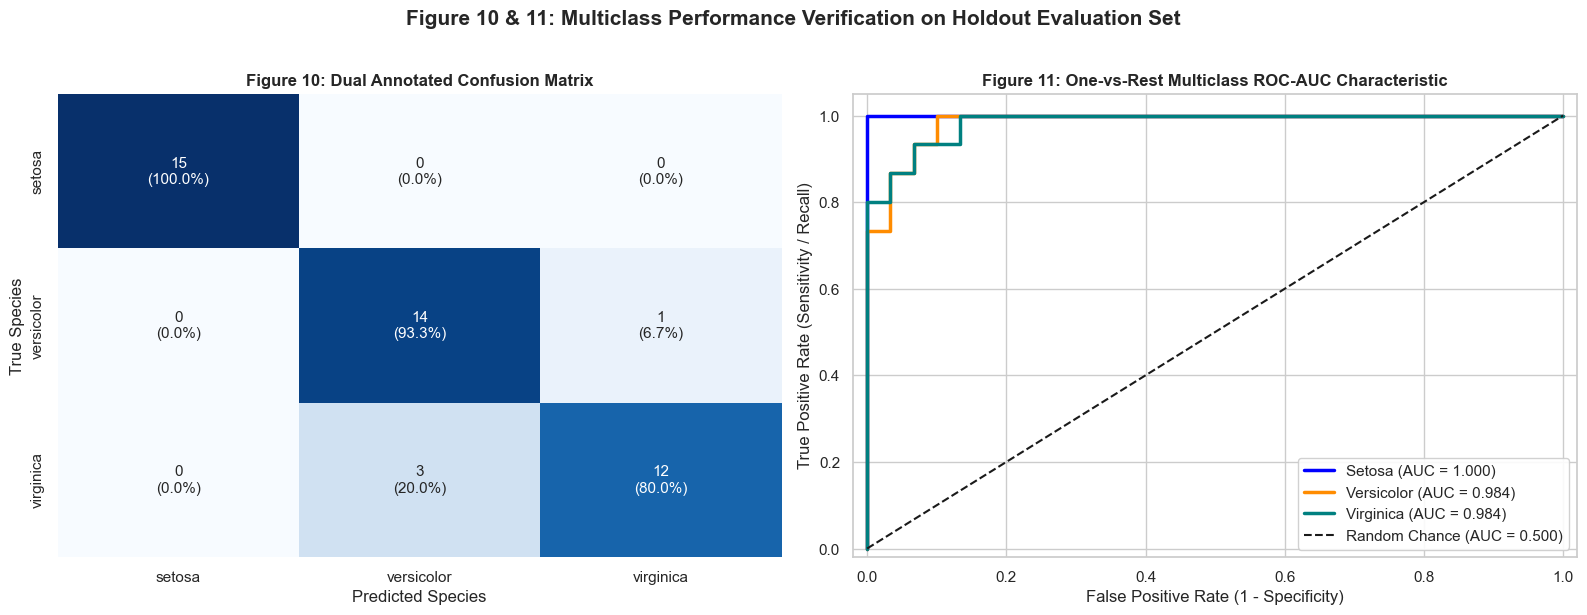

In [15]:
# Evaluate the tuned model on the unseen test set
y_pred_tuned = best_knn.predict(X_test)
y_pred_proba = best_knn.predict_proba(X_test)

final_acc = accuracy_score(y_test, y_pred_tuned)
print(f"Final Tuned KNN Classifier Accuracy: {final_acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=raw_iris.target_names))

# PLOT 10 & 11: Confusion Matrix and Multiclass ROC Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Normalized Confusion Matrix with Annotations
cm = confusion_matrix(y_test, y_pred_tuned)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
annot_matrix = np.array([[f"{count}\n({norm*100:.1f}%)" for count, norm in zip(row_c, row_n)]
                         for row_c, row_n in zip(cm, cm_norm)])

sns.heatmap(cm, annot=annot_matrix, fmt='', cmap='Blues', ax=ax1,
            xticklabels=raw_iris.target_names, yticklabels=raw_iris.target_names, cbar=False)
ax1.set_title("Figure 10: Dual Annotated Confusion Matrix", fontweight='bold')
ax1.set_xlabel("Predicted Species")
ax1.set_ylabel("True Species")

# Subplot 2: Multiclass One-vs-Rest ROC-AUC Curves
colors = ['blue', 'darkorange', 'teal']
for i, (species_name, color) in enumerate(zip(raw_iris.target_names, colors)):
    y_binary = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_binary, y_pred_proba[:, i])
    roc_score = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color=color, linewidth=2.5,
             label=f'{species_name.title()} (AUC = {roc_score:.3f})')

# Diagonal random baseline
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Chance (AUC = 0.500)')
ax2.set_title("Figure 11: One-vs-Rest Multiclass ROC-AUC Characteristic", fontweight='bold')
ax2.set_xlabel("False Positive Rate (1 - Specificity)")
ax2.set_ylabel("True Positive Rate (Sensitivity / Recall)")
ax2.set_xlim([-0.02, 1.02])
ax2.set_ylim([-0.02, 1.05])
ax2.legend(loc='lower right', framealpha=0.9)

plt.suptitle("Figure 10 & 11: Multiclass Performance Verification on Holdout Evaluation Set", y=1.02, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

<a id="13-summary-takeaways"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">13. Task 13: Computational Complexity Analysis & Production Takeaways</span>


### 📊 Computational & Memory Complexity Breakdown

| Phase | Brute-Force KNN | KD-Tree Algorithm | Ball-Tree Algorithm |
| :--- | :--- | :--- | :--- |
| **Model Training** | $O(1)$ (No computation, stores samples) | $O(d \cdot N \log N)$ | $O(d \cdot N \log N)$ |
| **Inference per Query** | $O(d \cdot N)$ | $O(d \cdot \log N)$ (Degrades if $d > 20$) | $O(d \cdot \log N)$ (Effective for high-dim) |
| **Memory Footprint** | $O(d \cdot N)$ | $O(d \cdot N)$ | $O(d \cdot N)$ |

### 🔑 Key Engineering Takeaways:
1. **Curse of Dimensionality**: As feature dimensions $d$ increase, pairwise Euclidean distance collapses (distance to nearest neighbor approaches distance to farthest neighbor). Always pair KNN with PCA or feature selection in high dimensions.
2. **Feature Normalization is Mandatory**: Distance metrics cannot operate on raw unscaled features with different units or standard deviations.
3. **Hyperparameter Selection**: Odd values of $k$ prevent tie-breaks in binary problems; Stratified $K$-Fold cross-validation avoids overfitting to holdout partitions.
4. **Distance Weighting Advantage**: Using `weights='distance'` guarantees that closer training points exert more influence than distant marginal samples.
